# Measurement: Time and CPU utilization
Here we will look at the CPU utilization and time required on the actual **Z2** board using the MNIST data base. The scope will be contained to smaller greyscale images only. the metrics will be compared by using custom 3x3 kernel convolution code and then using libraries. Which will later be used for comparison if the Acclerator improved the flow or not.    

In [24]:
#loading in imports
import os
import time
import psutil
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from PIL import Image
print("Imports Completed")

Imports Completed


In [18]:
#To check if folder access works and the files are present
def count_images(directory):
    if not os.path.exists(directory):
        return f"Error: The directory '{directory}' does not exist."
    
    count = 0
    # os.walk goes through the folder and any subfolders
    print("Working, it found the folder")
    for root, dirs, files in os.walk(directory):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                count += 1
    
    return count

In [19]:
folder_path = 'testSet' 
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
image_count = count_images(folder_path)
print(f"Total images found in '{folder_path}': {image_count}")

Working, it found the folder
Total images found in 'testSet': 28000


Starting benchmark on 28,000 images...
Processed 5,000 / 28,000 images...
Processed 10,000 / 28,000 images...
Processed 15,000 / 28,000 images...
Processed 20,000 / 28,000 images...
Processed 25,000 / 28,000 images...

Benchmark Complete!
Total Wall Time: 103.54 seconds (1.73 minutes)


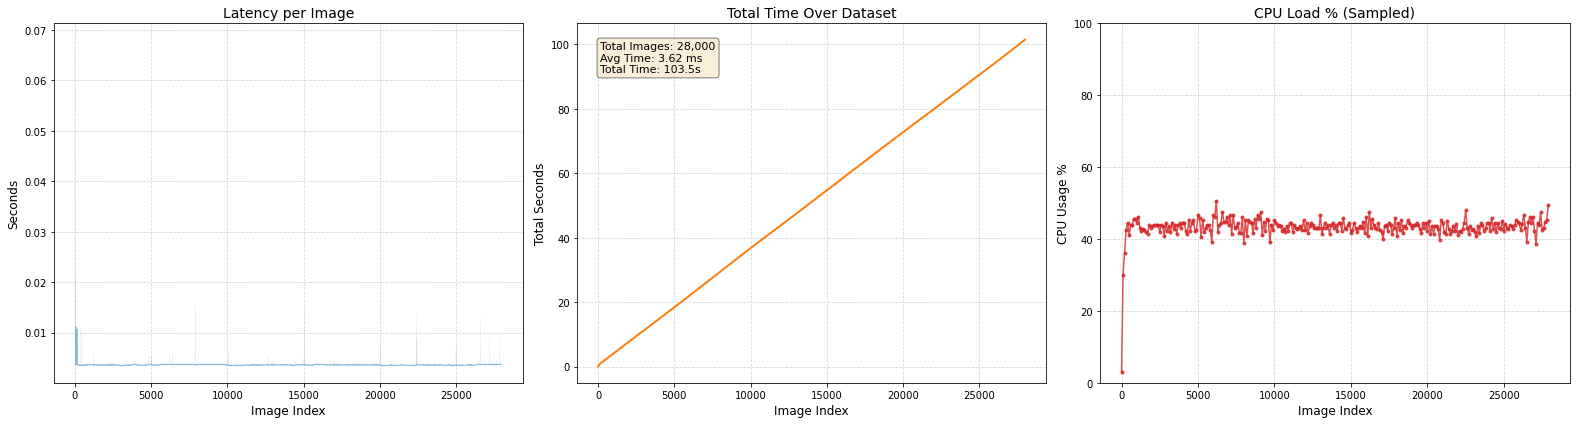

In [25]:
# Standard 3x3 Edge Detection (Sobel) Kernel
kernel = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]])

# Lists to store our metrics
image_times = []
cpu_samples = []
sample_indices = []

# 2. Preparation
if not os.path.exists(folder_path):
    print(f"Error: Folder '{folder_path}' not found. Please check your path.")
else:
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(image_extensions)]
    total_files = len(files)
    print(f"Starting benchmark on {total_files:,} images...")

    start_bench_time = time.perf_counter()

    # 3. Processing Loop
    for i, filename in enumerate(files):
        img_path = os.path.join(folder_path, filename)
        
        try:
            # Measure specific image latency
            t_start = time.perf_counter()
            
            # Load and Process
            img = Image.open(img_path).convert('L') # Grayscale
            img_array = np.array(img)
            _ = convolve2d(img_array, kernel, mode='same')
            
            t_end = time.perf_counter()
            image_times.append(t_end - t_start)
            
            # Sample CPU usage every 100 images to monitor load trend
            if i % 100 == 0:
                cpu_samples.append(psutil.cpu_percent())
                sample_indices.append(i)
                
            # Print progress every 5000 images
            if i % 5000 == 0 and i > 0:
                print(f"Processed {i:,} / {total_files:,} images...")
                
        except Exception as e:
            print(f"Skipping {filename}: {e}")

    end_bench_time = time.perf_counter()
    
    # 4. Data Calculation
    cumulative_time = np.cumsum(image_times)
    total_duration_sec = end_bench_time - start_bench_time
    total_duration_min = total_duration_sec / 60

    print("\nBenchmark Complete!")
    print(f"Total Wall Time: {total_duration_sec:.2f} seconds ({total_duration_min:.2f} minutes)")

    # 5. Create 3-Panel Visualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

    # Plot 1: Latency per Image (Blue)
    ax1.plot(image_times, color='#1f77b4', linewidth=0.1, alpha=0.5)
    ax1.set_title(f'Latency per Image', fontsize=14)
    ax1.set_xlabel('Image Index', fontsize=12)
    ax1.set_ylabel('Seconds', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Cumulative Total Time (Orange)
    ax2.plot(cumulative_time, color='#ff7f0e', linewidth=2)
    ax2.set_title('Total Time Over Dataset', fontsize=14)
    ax2.set_xlabel('Image Index', fontsize=12)
    ax2.set_ylabel('Total Seconds', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Text box for final stats on the second plot
    stats_text = (f"Total Images: {len(image_times):,}\n"
                  f"Avg Time: {np.mean(image_times)*1000:.2f} ms\n"
                  f"Total Time: {total_duration_sec:.1f}s")
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    # Plot 3: CPU Usage Trend (Red)
    ax3.plot(sample_indices, cpu_samples, color='#d62728', marker='o', markersize=3, alpha=0.8)
    ax3.set_title('CPU Load % (Sampled)', fontsize=14)
    ax3.set_xlabel('Image Index', fontsize=12)
    ax3.set_ylabel('CPU Usage %', fontsize=12)
    ax3.set_ylim(0, 100)
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
 # ... (rest of your plotting code)


    plt.savefig('convolution_benchmark_ARM.png', facecolor='white', bbox_inches='tight')
    plt.show()